In [1]:
import pandas as pd

df=pd.read_csv("/Users/khushiteli/NYC/MTA_Subway_Hourly_Ridership.csv")
df.head()

,transit_timestamp,transit_mode,station_complex_id,station_complex,borough,payment_method,fare_class_category,ridership,transfers,latitude,longitude,Georeference
0,12/31/2023 01:00:00 AM,subway,610,"Grand Central-42 St (S,4,5,6,7)",Manhattan,metrocard,Metrocard - Unlimited 30-Day,23,0,40.751778,-73.976845,POINT (-73.976845 40.751778)
1,12/31/2023 01:00:00 AM,subway,610,"Grand Central-42 St (S,4,5,6,7)",Manhattan,metrocard,Metrocard - Seniors & Disability,3,0,40.751778,-73.976845,POINT (-73.976845 40.751778)
2,12/31/2023 01:00:00 AM,subway,611,"Times Sq-42 St (N,Q,R,W,S,1,2,3,7)/42 St (A,C,E)",Manhattan,omny,OMNY - Seniors & Disability,1,0,40.755290,-73.987495,POINT (-73.987495 40.75529)
3,12/31/2023 01:00:00 AM,subway,610,"Grand Central-42 St (S,4,5,6,7)",Manhattan,omny,OMNY - Full Fare,211,0,40.751778,-73.976845,POINT (-73.976845 40.751778)
4,12/31/2023 01:00:00 AM,subway,610,"Grand Central-42 St (S,4,5,6,7)",Manhattan,metrocard,Metrocard - Full Fare,64,1,40.751778,-73.976845,POINT (-73.976845 40.751778)


In [2]:
df.columns

Index(['transit_timestamp', 'transit_mode', 'station_complex_id',
       'station_complex', 'borough', 'payment_method', 'fare_class_category',
       'ridership', 'transfers', 'latitude', 'longitude', 'Georeference'],
      dtype='object')

In [3]:
cols_to_keep = ["transit_timestamp", "station_complex", "ridership"]
df = df[cols_to_keep].copy()

df.head()

,transit_timestamp,station_complex,ridership
0,12/31/2023 01:00:00 AM,"Grand Central-42 St (S,4,5,6,7)",23
1,12/31/2023 01:00:00 AM,"Grand Central-42 St (S,4,5,6,7)",3
2,12/31/2023 01:00:00 AM,"Times Sq-42 St (N,Q,R,W,S,1,2,3,7)/42 St (A,C,E)",1
3,12/31/2023 01:00:00 AM,"Grand Central-42 St (S,4,5,6,7)",211
4,12/31/2023 01:00:00 AM,"Grand Central-42 St (S,4,5,6,7)",64


In [4]:
df["transit_timestamp"] = pd.to_datetime(df["transit_timestamp"])

# If ridership came as strings with commas, this handles it safely
df["ridership"] = (
    df["ridership"]
      .astype(str)
      .str.replace(",", "", regex=False)
)

df["ridership"] = pd.to_numeric(df["ridership"], errors="coerce")

# Drop rows where ridership couldn't be parsed
df = df.dropna(subset=["ridership"])

print(df.dtypes)
df.head()

transit_timestamp    datetime64[ns]
station_complex              object
ridership                     int64
dtype: object


,transit_timestamp,station_complex,ridership
0,2023-12-31 01:00:00,"Grand Central-42 St (S,4,5,6,7)",23
1,2023-12-31 01:00:00,"Grand Central-42 St (S,4,5,6,7)",3
2,2023-12-31 01:00:00,"Times Sq-42 St (N,Q,R,W,S,1,2,3,7)/42 St (A,C,E)",1
3,2023-12-31 01:00:00,"Grand Central-42 St (S,4,5,6,7)",211
4,2023-12-31 01:00:00,"Grand Central-42 St (S,4,5,6,7)",64


In [16]:
# 1. Sort correctly
df = df.sort_values(["station_complex", "transit_timestamp"])

# 2. Compute hourly ridership from cumulative
df["hourly_ridership"] = (
    df.groupby("station_complex")["ridership"]
      .diff()
)

# 3. Drop first diff per station (NaN)
df = df.dropna(subset=["hourly_ridership"])

# 4. Remove impossible values (counter resets)
df = df[df["hourly_ridership"] >= 0]

# 5. Aggregate to ONE row per station per hour (THIS IS CRITICAL)
df = (
    df.groupby(["station_complex", "transit_timestamp"], as_index=False)
      .agg({"hourly_ridership": "sum"})
)


/var/folders/47/kkwt6vl138xcd5y3tqq_05_m0000gn/T/ipykernel_6418/3483055062.py:19: FutureWarning: A grouping was used that is not in the columns of the DataFrame and so was excluded from the result. This grouping will be included in a future version of pandas. Add the grouping as a column of the DataFrame to silence this warning.
  .agg({"hourly_ridership": "sum"})


In [5]:
df = df.sort_values(["station_complex", "transit_timestamp"])
df.head()

,transit_timestamp,station_complex,ridership
0,2023-12-31 01:00:00,"Grand Central-42 St (S,4,5,6,7)",23
1,2023-12-31 01:00:00,"Grand Central-42 St (S,4,5,6,7)",3
3,2023-12-31 01:00:00,"Grand Central-42 St (S,4,5,6,7)",211
4,2023-12-31 01:00:00,"Grand Central-42 St (S,4,5,6,7)",64
7,2023-12-31 01:00:00,"Grand Central-42 St (S,4,5,6,7)",17


In [6]:
df["hourly_ridership"] = (
    df.groupby("station_complex")["ridership"]
      .diff()
)

# Drop the first row per station (diff = NaN)
df = df.dropna(subset=["hourly_ridership"])

In [7]:
# Negative demand is not possible: treat as invalid for forecasting
df = df[df["hourly_ridership"] >= 0]

In [8]:
df = (
    df.groupby(["station_complex", "transit_timestamp"], as_index=False)
      .agg({"hourly_ridership": "sum"})
)

df.head()

,station_complex,transit_timestamp,hourly_ridership
0,"Grand Central-42 St (S,4,5,6,7)",2023-12-31 01:00:00,237.0
1,"Grand Central-42 St (S,4,5,6,7)",2023-12-31 02:00:00,103.0
2,"Grand Central-42 St (S,4,5,6,7)",2023-12-31 03:00:00,29.0
3,"Grand Central-42 St (S,4,5,6,7)",2023-12-31 04:00:00,26.0
4,"Grand Central-42 St (S,4,5,6,7)",2023-12-31 05:00:00,51.0


In [9]:
print("Rows:", len(df))
print("Stations:", df["station_complex"].nunique())

df["hourly_ridership"].describe()

Rows: 17564
Stations: 2


count    17564.000000
mean      3452.802892
std       2951.208256
min          3.000000
25%        969.000000
50%       3153.000000
75%       4892.000000
max      18903.000000
Name: hourly_ridership, dtype: float64

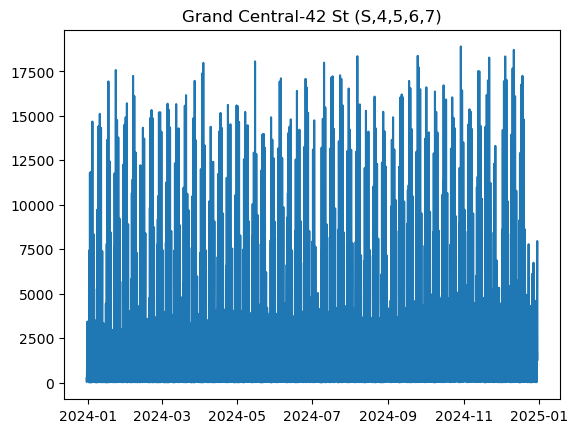

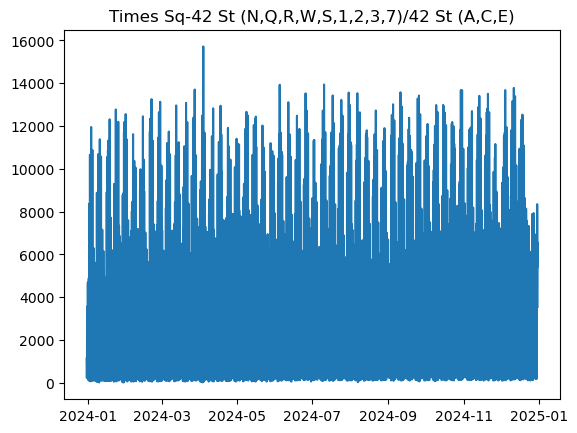

In [11]:
import matplotlib.pyplot as plt
for station in df["station_complex"].unique():
    subset = df[df["station_complex"] == station]
    plt.figure()
    plt.plot(subset["transit_timestamp"], subset["hourly_ridership"])
    plt.title(station)
    plt.show()

In [12]:
df = df.copy()

df["transit_timestamp"] = pd.to_datetime(df["transit_timestamp"])

df = df.sort_values(["station_complex", "transit_timestamp"])
df = df.set_index("transit_timestamp")

In [13]:
station_dfs = []

for station, g in df.groupby("station_complex"):
    full_index = pd.date_range(
        start=g.index.min(),
        end=g.index.max(),
        freq="h"
    )
    
    g = g.reindex(full_index)
    g["station_complex"] = station
    
    station_dfs.append(g)

df_full = (
    pd.concat(station_dfs)
      .rename_axis("transit_timestamp")
      .reset_index()
)

In [14]:
df_full["hourly_ridership"].isna().groupby(df_full["station_complex"]).sum()

station_complex
Grand Central-42 St (S,4,5,6,7)                     1
Times Sq-42 St (N,Q,R,W,S,1,2,3,7)/42 St (A,C,E)    1
Name: hourly_ridership, dtype: int64

In [15]:
(
    df_full["hourly_ridership"].isna()
    .groupby(df_full["station_complex"])
    .mean()
    .mul(100)
)

station_complex
Grand Central-42 St (S,4,5,6,7)                     0.011386
Times Sq-42 St (N,Q,R,W,S,1,2,3,7)/42 St (A,C,E)    0.011386
Name: hourly_ridership, dtype: float64

In [16]:
df_full["hourly_ridership_filled"] = df_full["hourly_ridership"].fillna(0)

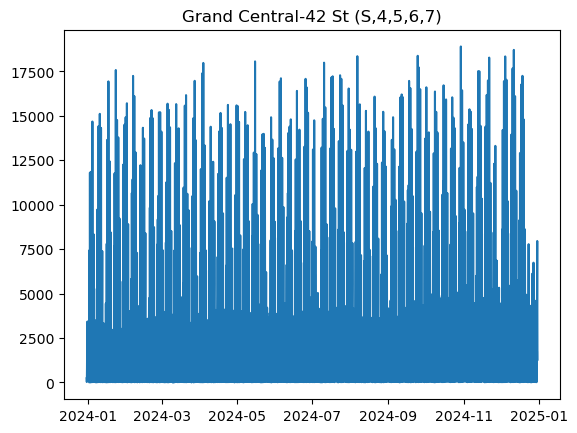

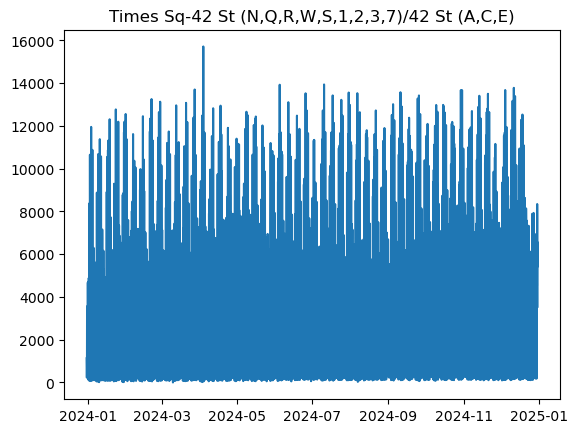

In [17]:
for station in df_full["station_complex"].unique():
    subset = df_full[df_full["station_complex"] == station]
    plt.figure()
    plt.plot(
        subset["transit_timestamp"],
        subset["hourly_ridership_filled"]
    )
    plt.title(station)
    plt.show()

In [18]:
df_ts = df_full.copy()

df_ts = df_ts.sort_values(["station_complex", "transit_timestamp"])

# Use the filled demand from Step 6
df_ts["y"] = df_ts["hourly_ridership_filled"]

In [19]:
HORIZON = 24 * 7  # one week

train_test = {}

for station, g in df_ts.groupby("station_complex"):
    train = g.iloc[:-HORIZON]
    test  = g.iloc[-HORIZON:]
    
    train_test[station] = (train, test)

In [20]:
baseline_results = []

for station, (train, test) in train_test.items():
    y_last = train["y"].iloc[-1]
    y_pred = [y_last] * len(test)
    
    baseline_results.append({
        "station": station,
        "baseline": "naive",
        "mae": (test["y"] - y_pred).abs().mean()
    })

In [23]:
import numpy as np

for station, (train, test) in train_test.items():
    y_pred = train["y"].iloc[-24:].values
    y_pred = list(y_pred) * (len(test) // 24 + 1)

    baseline_results.append({
        "station": station,
        "baseline": "seasonal_naive_24h",
        "mae": np.mean(
            np.abs(test["y"].values - y_pred[:len(test)])
        )
    })

In [24]:
baseline_df = pd.DataFrame(baseline_results)
baseline_df

,station,baseline,mae
0,"Grand Central-42 St (S,4,5,6,7)",naive,1614.285714
1,"Times Sq-42 St (N,Q,R,W,S,1,2,3,7)/42 St (A,C,E)",naive,2293.726190
2,"Grand Central-42 St (S,4,5,6,7)",seasonal_naive_24h,923.726190
3,"Times Sq-42 St (N,Q,R,W,S,1,2,3,7)/42 St (A,C,E)",seasonal_naive_24h,938.863095


In [25]:
df_ml = df_full.copy()

df_ml = df_ml.sort_values(["station_complex", "transit_timestamp"])

df_ml["y"] = (
    df_ml
    .groupby("station_complex")["hourly_ridership_filled"]
    .shift(-24)
)

In [26]:
LAGS = [1, 2, 3, 24, 48, 168]  # last hour, yesterday, last week

for lag in LAGS:
    df_ml[f"lag_{lag}"] = (
        df_ml
        .groupby("station_complex")["hourly_ridership_filled"]
        .shift(lag)
    )

In [27]:
df_ml["rolling_mean_24"] = (
    df_ml
    .groupby("station_complex")["hourly_ridership_filled"]
    .shift(1)
    .rolling(24)
    .mean()
)

df_ml["rolling_std_24"] = (
    df_ml
    .groupby("station_complex")["hourly_ridership_filled"]
    .shift(1)
    .rolling(24)
    .std()
)

In [28]:
df_ml["hour"] = df_ml["transit_timestamp"].dt.hour
df_ml["day_of_week"] = df_ml["transit_timestamp"].dt.dayofweek
df_ml["is_weekend"] = df_ml["day_of_week"].isin([5, 6]).astype(int)

In [29]:
df_ml = df_ml.dropna()

In [34]:
FEATURES = [
    "lag_1", "lag_2", "lag_3", "lag_24", "lag_48", "lag_168",
    "rolling_mean_24", "rolling_std_24",
    "hour", "day_of_week", "is_weekend"
]

TARGET = "y"

In [35]:
HORIZON = 24 * 7  # 1 week

train_test_ml = {}

for station, g in df_ml.groupby("station_complex"):
    g = g.sort_values("transit_timestamp")
    train = g.iloc[:-HORIZON]
    test  = g.iloc[-HORIZON:]
    
    train_test_ml[station] = (train, test)

In [36]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

ml_results = []

for station, (train, test) in train_test_ml.items():
    X_train = train[FEATURES]
    y_train = train[TARGET]
    X_test  = test[FEATURES]
    y_test  = test[TARGET]
    
    model = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    ml_results.append({
        "station": station,
        "model": "GradientBoosting",
        "mae": mean_absolute_error(y_test, y_pred)
    })

In [37]:
ml_results_df = pd.DataFrame(ml_results)
ml_results_df

,station,model,mae
0,"Grand Central-42 St (S,4,5,6,7)",GradientBoosting,1302.284325
1,"Times Sq-42 St (N,Q,R,W,S,1,2,3,7)/42 St (A,C,E)",GradientBoosting,1153.237214


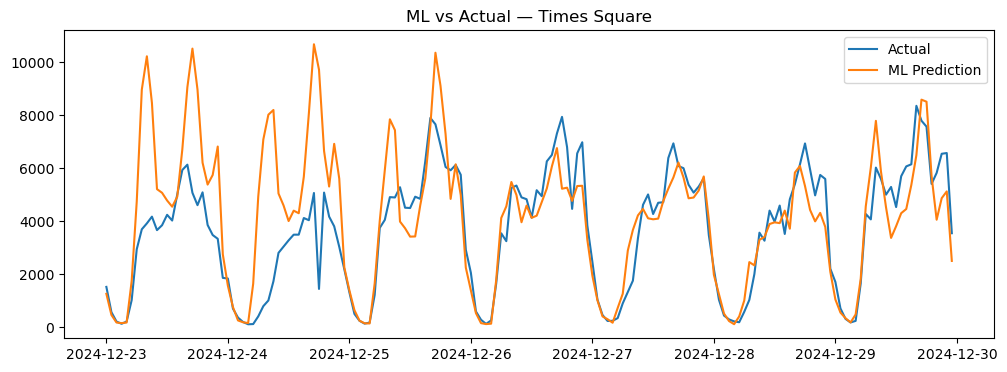

In [38]:
station = "Times Sq-42 St (N,Q,R,W,S,1,2,3,7)/42 St (A,C,E)"

train, test = train_test_ml[station]

model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)
model.fit(train[FEATURES], train[TARGET])
pred = model.predict(test[FEATURES])

plt.figure(figsize=(12,4))
plt.plot(test["transit_timestamp"], test[TARGET], label="Actual")
plt.plot(test["transit_timestamp"], pred, label="ML Prediction")
plt.legend()
plt.title("ML vs Actual — Times Square")
plt.show()


In [39]:
# Same hour yesterday (strongest signal)
df_ml["same_hour_yesterday"] = (
    df_ml.groupby("station_complex")["hourly_ridership_filled"]
          .shift(24)
)

# Same hour last week
df_ml["same_hour_last_week"] = (
    df_ml.groupby("station_complex")["hourly_ridership_filled"]
          .shift(168)
)

In [40]:
df_ml = df_ml.dropna()

In [41]:
FEATURES += ["same_hour_yesterday", "same_hour_last_week"]

In [42]:
HORIZON = 24 * 7  # 1 week

train_test_ml = {}

for station, g in df_ml.groupby("station_complex"):
    g = g.sort_values("transit_timestamp")
    train = g.iloc[:-HORIZON]
    test  = g.iloc[-HORIZON:]
    
    train_test_ml[station] = (train, test)

In [43]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

ml_results_updated = []

for station, (train, test) in train_test_ml.items():
    X_train = train[FEATURES]
    y_train = train["y"]
    X_test  = test[FEATURES]
    y_test  = test["y"]
    
    model = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    ml_results_updated.append({
        "station": station,
        "model": "GradientBoosting + AR features",
        "mae": mean_absolute_error(y_test, y_pred)
    })

In [44]:
ml_results_updated_df = pd.DataFrame(ml_results_updated)
ml_results_updated_df

,station,model,mae
0,"Grand Central-42 St (S,4,5,6,7)",GradientBoosting + AR features,1265.179954
1,"Times Sq-42 St (N,Q,R,W,S,1,2,3,7)/42 St (A,C,E)",GradientBoosting + AR features,1165.494208


In [45]:
RIDERS_PER_STAFF = 250

In [46]:
baseline_df["staff_error"] = baseline_df["mae"] / RIDERS_PER_STAFF
baseline_df

,station,baseline,mae,staff_error
0,"Grand Central-42 St (S,4,5,6,7)",naive,1614.285714,6.457143
1,"Times Sq-42 St (N,Q,R,W,S,1,2,3,7)/42 St (A,C,E)",naive,2293.726190,9.174905
2,"Grand Central-42 St (S,4,5,6,7)",seasonal_naive_24h,923.726190,3.694905
3,"Times Sq-42 St (N,Q,R,W,S,1,2,3,7)/42 St (A,C,E)",seasonal_naive_24h,938.863095,3.755452


In [47]:
COST_UNDER = 120   # $ per staff-hour (missed service, delays)
COST_OVER  = 40    # $ per staff-hour (idle labor)

In [48]:
baseline_df["hourly_cost"] = (
    (baseline_df["staff_error"] / 2) * COST_UNDER +
    (baseline_df["staff_error"] / 2) * COST_OVER
)

baseline_df

,station,baseline,mae,staff_error,hourly_cost
0,"Grand Central-42 St (S,4,5,6,7)",naive,1614.285714,6.457143,516.571429
1,"Times Sq-42 St (N,Q,R,W,S,1,2,3,7)/42 St (A,C,E)",naive,2293.726190,9.174905,733.992381
2,"Grand Central-42 St (S,4,5,6,7)",seasonal_naive_24h,923.726190,3.694905,295.592381
3,"Times Sq-42 St (N,Q,R,W,S,1,2,3,7)/42 St (A,C,E)",seasonal_naive_24h,938.863095,3.755452,300.436190


In [49]:
baseline_df["weekly_cost"] = baseline_df["hourly_cost"] * 24 * 7
baseline_df

,station,baseline,mae,staff_error,hourly_cost,weekly_cost
0,"Grand Central-42 St (S,4,5,6,7)",naive,1614.285714,6.457143,516.571429,86784.00
1,"Times Sq-42 St (N,Q,R,W,S,1,2,3,7)/42 St (A,C,E)",naive,2293.726190,9.174905,733.992381,123310.72
2,"Grand Central-42 St (S,4,5,6,7)",seasonal_naive_24h,923.726190,3.694905,295.592381,49659.52
3,"Times Sq-42 St (N,Q,R,W,S,1,2,3,7)/42 St (A,C,E)",seasonal_naive_24h,938.863095,3.755452,300.436190,50473.28


In [50]:
baseline_df["weekly_cost"] = baseline_df["hourly_cost"] * 24 * 7
baseline_df

,station,baseline,mae,staff_error,hourly_cost,weekly_cost
0,"Grand Central-42 St (S,4,5,6,7)",naive,1614.285714,6.457143,516.571429,86784.00
1,"Times Sq-42 St (N,Q,R,W,S,1,2,3,7)/42 St (A,C,E)",naive,2293.726190,9.174905,733.992381,123310.72
2,"Grand Central-42 St (S,4,5,6,7)",seasonal_naive_24h,923.726190,3.694905,295.592381,49659.52
3,"Times Sq-42 St (N,Q,R,W,S,1,2,3,7)/42 St (A,C,E)",seasonal_naive_24h,938.863095,3.755452,300.436190,50473.28


In [51]:
baseline_df.to_csv("staffing_cost_comparison.csv", index=False)

In [52]:
forecast_df = test.copy()
forecast_df["forecast"] = y_pred

forecast_df = forecast_df[[
    "transit_timestamp",
    "station_complex",
    "y",
    "forecast"
]]

forecast_df.to_csv("times_square_forecast_vs_actual.csv", index=False)

In [53]:
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor

HORIZON = 24 * 7

forecast_rows = []

for station, (train, test) in train_test_ml.items():
    X_train = train[FEATURES]
    y_train = train["y"]
    X_test  = test[FEATURES]
    y_test  = test["y"]

    # SAME model & hyperparameters you used
    model = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    out = test[["transit_timestamp", "station_complex"]].copy()
    out["y"] = y_test.values
    out["forecast"] = y_pred
    out["model"] = "GradientBoosting"   # optional label for Power BI
    forecast_rows.append(out)

forecast_all = pd.concat(forecast_rows, ignore_index=True)

forecast_all.shape, forecast_all["station_complex"].nunique(), forecast_all["station_complex"].unique()

((336, 5),
 2,
 array(['Grand Central-42 St (S,4,5,6,7)',
        'Times Sq-42 St (N,Q,R,W,S,1,2,3,7)/42 St (A,C,E)'], dtype=object))

In [54]:
RIDERS_PER_STAFF = 250
forecast_all["staff_required"] = forecast_all["forecast"] / RIDERS_PER_STAFF
forecast_all["staff_actual"]   = forecast_all["y"] / RIDERS_PER_STAFF

In [55]:
forecast_all.to_csv("forecast_vs_actual_all_stations.csv", index=False)